In [ ]:
#multilinear regression

In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/cardata.csv')
print('Car dataset loaded successfully.')

Car dataset loaded successfully.


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
df.shape

(301, 9)

In [ ]:
#count occurance of each Fuel_type in the dataset
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [ ]:
#count occurance of seller_type in the dataset
df['Seller_Type'].value_counts()


,count
Seller_Type,
Dealer,195
Individual,106


In [ ]:
#count occurance of each transmission type in the dataset
df['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [ ]:
#one hot encoding
df = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'])

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Owner', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Seller_Type_Dealer', 'Seller_Type_Individual',
       'Transmission_Automatic', 'Transmission_Manual'],
      dtype='object')

In [ ]:
#create feature matrix x b dropping car_name and selling_price columns
x = df.drop(['Car_Name', 'Selling_Price'], axis=1)
print("Feature matrix created successfully.")

Feature matrix created successfully.


In [ ]:
#select target vector y containing the selling_price column
y = df['Selling_Price']
print("Target vector created successfully.")

Target vector created successfully.


In [ ]:
x.head()

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,2014,5.59,27000,0,False,False,True,True,False,False,True
1,2013,9.54,43000,0,False,True,False,True,False,False,True
2,2017,9.85,6900,0,False,False,True,True,False,False,True
3,2011,4.15,5200,0,False,False,True,True,False,False,True
4,2014,6.87,42450,0,False,True,False,True,False,False,True


In [ ]:
#create the model
model = LinearRegression()
print("Model created successfully.")

Model created successfully.


In [ ]:
#train the model
model.fit(x, y)
print("Model trained successfully.")

Model trained successfully.


In [ ]:
# Split the data into training and testing sets
# Note: This step should ideally be in its own cell, but is included here to resolve the error.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Generate predictions for training and testing the data
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)
print("Predictions generated for training and testing data")

Predictions generated for training and testing data


In [ ]:
#Evaluate the model performance on training and testing
train_mae=mean_absolute_error(y_train,y_train_pred)
train_mse=mean_squared_error(y_train,y_train_pred)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train,y_train_pred)
print("Model performance on training data:")
print("Mean Absolute Error (MAE):",train_mae)
print("Mean Squared Error (MSE):",train_mse)
print("Root Mean Squared Error (RMSE):",train_rmse)
print("R-squared: ",train_r2)

Model performance on training data:
Mean Absolute Error (MAE): 1.1692187935526512
Mean Squared Error (MSE): 2.9718698904531613
Root Mean Squared Error (RMSE): 1.723911218843117
R-squared:  0.8875869613859126


In [ ]:
test_mae=mean_absolute_error(y_test,y_test_pred)
test_mse=mean_squared_error(y_test,y_test_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test,y_test_pred)
print("\nModel performance on testing data:")
print("Mean Absolute Error (MAE):",test_mae)
print("Mean Squared Error (MSE):",test_mse)
print("Root Mean Squared Error (RMSE):",test_rmse)
print("R-squared: ",test_r2)


Model performance on testing data:
Mean Absolute Error (MAE): 1.1780981824759056
Mean Squared Error (MSE): 3.227201203438042
Root Mean Squared Error (RMSE): 1.796441260781449
R-squared:  0.8599036546871449


In [ ]:
#coefficients and intercepts
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 3.93084982e-01  4.37174007e-01 -7.01321414e-06 -6.74167769e-01
 -1.02586413e+00  1.44407116e+00 -4.18207030e-01  5.60657497e-01
 -5.60657497e-01  7.24086200e-01 -7.24086200e-01]
Intercept: -789.4954402923628


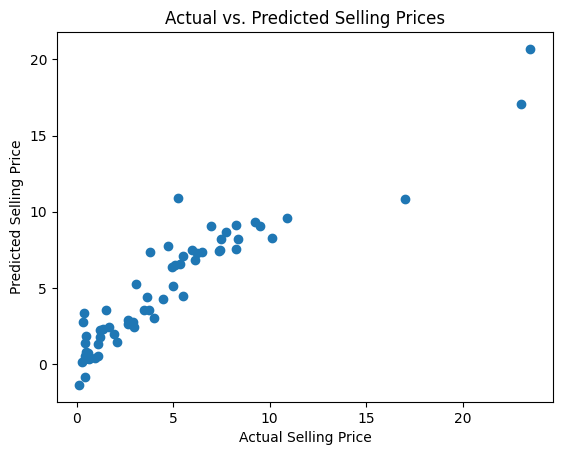

In [ ]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs. Predicted Selling Prices")
plt.show()